In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from xgboost import XGBRegressor

In [3]:
data_dir = './DATA/'
filename = '2023_clean.csv'

In [4]:
df_raw = pd.read_csv(f'{data_dir}{filename}')
df_raw

,latitude,longitude,epa_o3,aster_dem,cams_col_o3,cams_surf_o3,cams_surf_no2,cams_surf_hcho,ceres_swf_all,era5_blh,...,era5_u10,era5_v10,modis_landtype,water_fraction,modis_ndvi,pop,viirs_ntl,doy,year,era5_t2m-d2m
0,25.58733,-80.32592,47.0,8.50,0.005805,57.70011,3.728535,0.898007,98.90685,838.2379,...,-3.377644,-4.859169,13.0,0.816232,4955.9390,971.0,29.19848,74,2023,6.1400
1,25.73288,-80.16175,52.0,6.00,0.005815,57.76892,3.325275,0.821489,97.68685,920.1100,...,-3.799672,-5.606412,17.0,0.814599,0.0000,541.0,25.49089,74,2023,6.5117
2,26.05389,-80.25694,49.0,7.25,0.005835,56.46091,3.421305,0.866421,106.24270,813.9014,...,-2.508782,-4.457390,13.0,0.804572,4404.9160,2260.0,42.33829,74,2023,7.3543
3,26.07354,-80.33845,45.0,6.75,0.005835,56.10865,3.300170,0.913606,108.91690,774.0244,...,-2.081585,-3.917842,13.0,0.802612,5528.4330,248.0,10.97885,74,2023,7.5945
4,26.08757,-80.11115,49.0,4.75,0.005839,57.03552,2.849112,0.798274,102.68090,900.7109,...,-2.786024,-4.935722,11.0,0.806499,2073.2290,507.0,24.97562,74,2023,7.0789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375363,48.29786,-124.62490,41.0,347.00,0.006828,42.42863,2.840825,0.799792,28.79292,566.4708,...,-2.415503,3.799192,1.0,0.183671,9151.0060,0.0,0.00000,309,2023,1.1626
375364,48.31751,-107.86250,35.0,750.75,0.006223,35.88940,1.632936,0.306875,53.67106,516.4257,...,4.925898,-0.016392,10.0,0.005111,-112.3374,0.0,0.00000,309,2023,6.2553
375365,48.41252,-92.82922,26.0,381.50,0.005994,36.50267,1.656441,0.266633,33.74514,493.7099,...,-2.505063,1.472806,8.0,0.111941,4976.9830,0.0,0.00000,309,2023,1.8844
375366,48.51030,-113.99680,34.0,971.00,0.006467,42.23070,2.121162,0.308139,66.52199,500.4874,...,0.949018,0.962373,8.0,0.007666,2393.2220,14.0,0.00000,309,2023,1.6947


In [5]:
target = "epa_o3"

feature_cols = [
    "latitude", "longitude",
    "aster_dem",
    "cams_col_o3", "cams_surf_o3", "cams_surf_no2", "cams_surf_hcho",
    "ceres_swf_all",
    "era5_blh", "era5_t2m", "era5_u10", "era5_v10", "era5_t2m-d2m",
    "modis_landtype", "water_fraction", "modis_ndvi",
    "pop", "viirs_ntl",
    "doy", "year"
]

data = df_raw[feature_cols + [target]].copy()
data = data.dropna(subset=[target])

X = data[feature_cols]
y = data[target]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
categorical_features = ["modis_landtype"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
xgb_reg = XGBRegressor(
    # Number of boosting rounds / trees.
    # XGBoost builds trees sequentially: each new tree tries to correct
    n_estimators=500,
    # Maximum depth of each individual tree.
    # Smaller depth makes each tree simpler and reduces overfitting.
    max_depth=4,
    # Shrinkage factor applied to each new tree.
    # A smaller learning rate makes boosting more conservative and usually
    # improves generalization, but requires more trees.
    learning_rate=0.05,
    # Minimum sum of instance weights needed in a child node.
    # Larger values make the model more conservative by preventing splits
    # that are supported by only a small number of samples.
    # This helps reduce overfitting and noisy small leaves.
    min_child_weight=5,
    # Fraction of training samples used for each tree.
    # subsample=0.8 means each tree sees 80% of the training data.
    # This adds randomness and helps reduce overfitting.
    subsample=0.8,
    # Fraction of features randomly selected for each tree.
    # colsample_bytree=0.8 means each tree uses 80% of the predictors.
    # This is useful when many predictors are correlated, such as meteorology,
    # chemistry, land-cover, and spatial variables.
    colsample_bytree=0.8,
    # L2 regularization strength on leaf weights.
    # Larger values penalize overly large leaf values and make the model smoother.
    # reg_lambda=1.0 is the standard default-like regularization level.
    reg_lambda=1.0,
    # Regression objective using squared-error loss.
    # Appropriate for continuous targets such as surface ozone concentration.
    objective="reg:squarederror",
    eval_metric="rmse",
    # Histogram-based tree construction.
    # This is usually faster and more memory-efficient than the exact method,
    # especially for large tabular datasets.
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

xgb_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("xgb", xgb_reg)
    ]
)

xgb_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mb_xgb = np.mean(y_pred_xgb - y_test)

print(f"XGBoost R²   = {r2_xgb:.3f}")
print(f"XGBoost RMSE = {rmse_xgb:.3f}")
print(f"XGBoost MAE  = {mae_xgb:.3f}")
print(f"XGBoost MB   = {mb_xgb:.3f}")

XGBoost R²   = 0.777
XGBoost RMSE = 5.792
XGBoost MAE  = 4.310
XGBoost MB   = -0.003


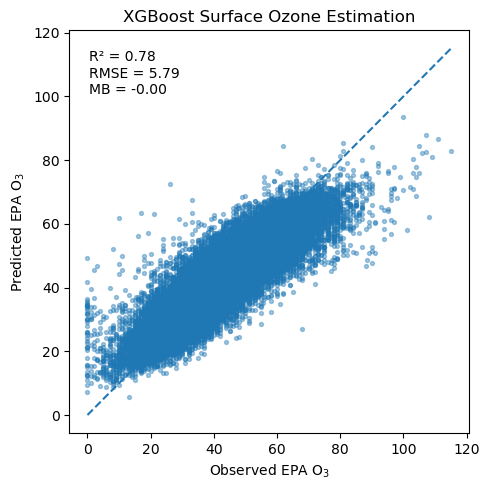

In [14]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_xgb, s=8, alpha=0.4)

min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed EPA O$_3$")
plt.ylabel("Predicted EPA O$_3$")
plt.title("XGBoost Surface Ozone Estimation")

plt.text(
    0.05, 0.95,
    f"R$^2$ = {r2_xgb:.2f}\nRMSE = {rmse_xgb:.2f}\nMB = {mb_xgb:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

In [15]:
preprocess_fitted = xgb_model.named_steps["preprocess"]
xgb_fitted = xgb_model.named_steps["xgb"]

num_names = numeric_features

cat_pipeline = preprocess_fitted.named_transformers_["cat"]
onehot = cat_pipeline.named_steps["onehot"]

try:
    cat_names = onehot.get_feature_names_out(categorical_features)
except AttributeError:
    cat_names = onehot.get_feature_names(categorical_features)

feature_names = np.concatenate([num_names, cat_names])

In [16]:
importance_values = xgb_fitted.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
}).sort_values("importance", ascending=False)

xgb_importance_df.head(20)

,feature,importance
4,cams_surf_o3,0.471764
7,ceres_swf_all,0.136810
2,aster_dem,0.042569
1,longitude,0.033787
12,era5_t2m-d2m,0.030610
5,cams_surf_no2,0.028373
27,modis_landtype_10.0,0.026234
14,modis_ndvi,0.020785
17,doy,0.019438
6,cams_surf_hcho,0.017115


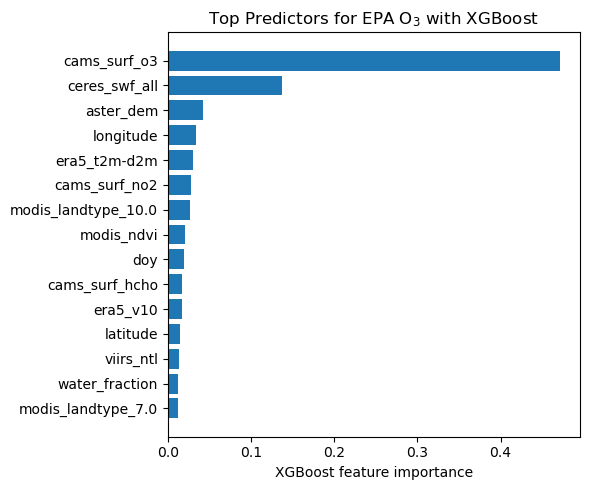

In [17]:
plot_df = xgb_importance_df.head(15).iloc[::-1]

plt.figure(figsize=(6, 5))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top Predictors for EPA O$_3$ with XGBoost")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.inspection import permutation_importance

n_sample = min(5000, len(X_test))

X_perm = X_test.sample(n=n_sample, random_state=42)
y_perm = y_test.loc[X_perm.index]

perm_xgb = permutation_importance(
    xgb_model,
    X_perm,
    y_perm,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    scoring="r2"
)

perm_xgb_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

perm_xgb_df.head(20)

,feature,importance_mean,importance_std
4,cams_surf_o3,0.610413,0.018240
7,ceres_swf_all,0.102370,0.002770
18,doy,0.075047,0.004056
1,longitude,0.068974,0.002842
2,aster_dem,0.048600,0.001831
5,cams_surf_no2,0.037401,0.001054
0,latitude,0.035200,0.001377
12,era5_t2m-d2m,0.026765,0.001487
9,era5_t2m,0.021143,0.001674
11,era5_v10,0.016033,0.000570


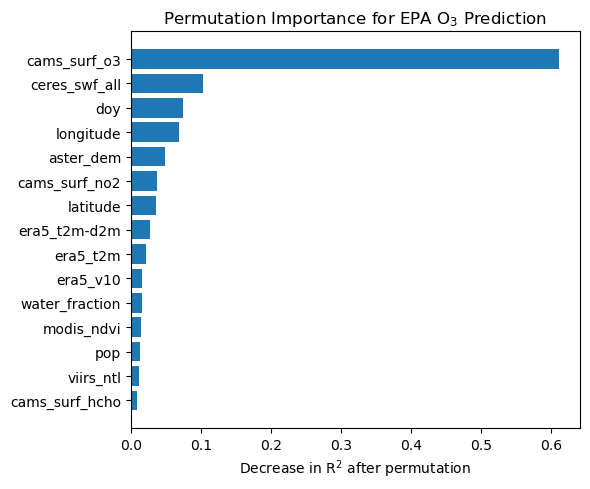

In [20]:
import matplotlib.pyplot as plt

plot_df = perm_xgb_df.head(15).iloc[::-1]

plt.figure(figsize=(6, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Decrease in R$^2$ after permutation")
plt.title("Permutation Importance for EPA O$_3$ Prediction")
plt.tight_layout()
plt.show()